# Projet Data Mining Analyse de données médicales

## I. Prétraitement des données : Breast Cancer Wisconsin Dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Chargement du CSV
df = pd.read_csv('data/diabetes.csv')

### Nettoyage des données manquantes et doublons

In [3]:
cols_avec_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_avec_zeros:
    df[col] = df[col].replace(0, np.nan)

# Remplissage par la médiane
df.fillna(df.median(), inplace=True)

# Suppression des doublons existants
df.drop_duplicates(inplace=True)
print(f"Nombre de lignes après nettoyage : {len(df)}")

Nombre de lignes après nettoyage : 768


Nous avons identifié des valeurs nulles aberrantes dans des colonnes comme l'insuline et l'IMC. Couper par la médiane permet de conserver la taille du dataset sans introduire d'erreurs.

### Encodage et Standardisation

In [4]:
from sklearn.calibration import LabelEncoder

# Encodage de la variable cible 'Outcome'
le = LabelEncoder()
df['Outcome'] = le.fit_transform(df['Outcome'])

# Standardisation des données
scaler = StandardScaler()
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

En appliquant une standardisation de type Z‑Score, qui ramène chaque variable à une moyenne de 0 et un écart‑type de 1, nous garantissons que le modèle KNN ne privilégie pas une variable simplement parce que ses valeurs sont plus grandes.

### Analyse exploratoire avec graphiques

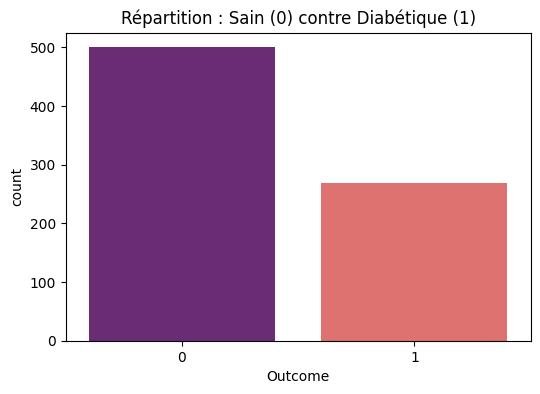

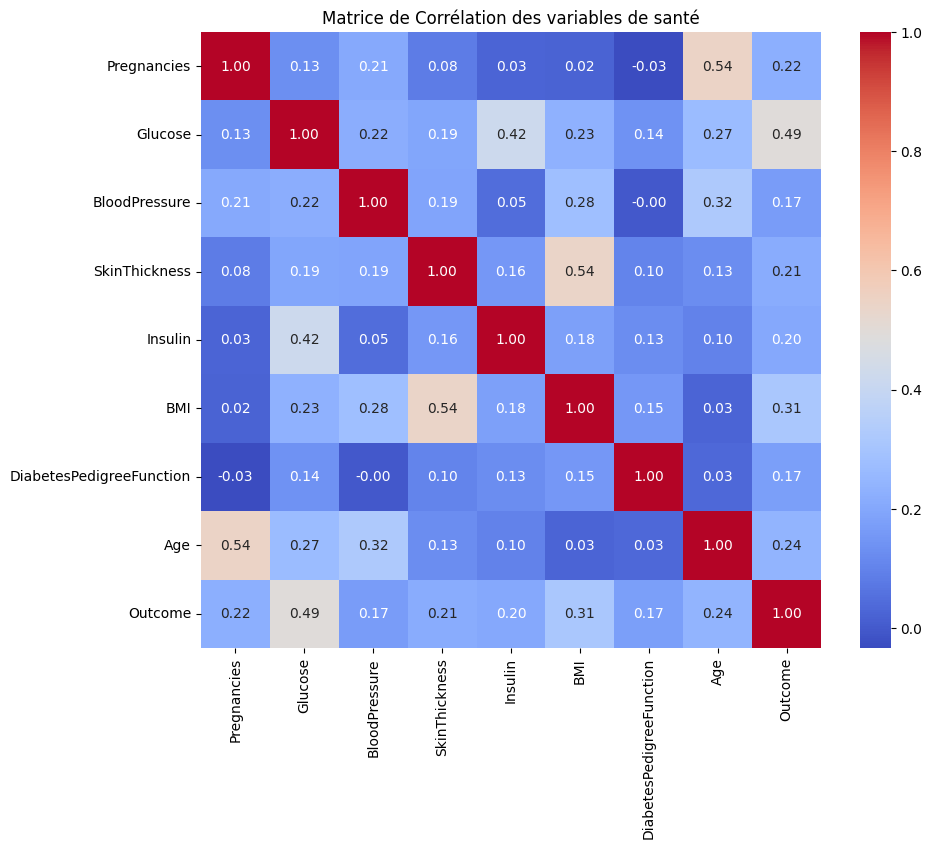

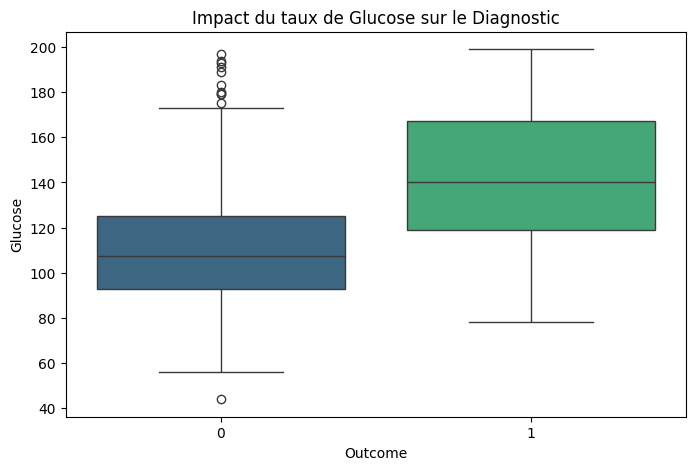

In [5]:
# Répartition des classes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', hue='Outcome', palette='magma', legend=False)
plt.title("Répartition : Sain (0) contre Diabétique (1)")
plt.show()

# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables de santé")
plt.show()

# Analyse de la distribution
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Outcome', y='Glucose', hue='Outcome', palette='viridis', legend=False)
plt.title("Impact du taux de Glucose sur le Diagnostic")
plt.show()

La matrice de corrélation montre que le Glucose et l'IMC ont la plus forte corrélation positive avec le diabète, ce qui confirme la pertinence des attributs choisis.

# II. Règles d’association

### Application d’Apriori - Extraction de règles

In [6]:
from mlxtend.frequent_patterns import apriori, association_rules

# Création du DataFrame, si la valeur est > médiane, on considère l'attribut comme élevé
df_assoc = pd.DataFrame()

for col in df.columns:
    if col != 'Outcome':
        df_assoc[col + '_High'] = df[col] > df[col].median()
    else:
        df_assoc['Diabetes_Positive'] = df['Outcome'] == 1

print(df_assoc.head())

   Pregnancies_High  Glucose_High  BloodPressure_High  SkinThickness_High  \
0              True          True               False                True   
1             False         False               False               False   
2              True          True               False               False   
3             False         False               False               False   
4             False          True               False                True   

   Insulin_High  BMI_High  DiabetesPedigreeFunction_High  Age_High  \
0         False      True                           True      True   
1         False     False                          False      True   
2         False     False                           True      True   
3         False     False                          False     False   
4          True      True                           True      True   

   Diabetes_Positive  
0               True  
1              False  
2               True  
3              False  
4

### Support (A → B)

In [7]:
# Support(A → B) = (Transactions contenant A ∪ B) / (Nombre total de transactions)
frequent_itemsets = apriori(df_assoc, min_support=0.1, use_colnames=True)

print("Nombre d'itemsets fréquents trouvés :", len(frequent_itemsets))
print(frequent_itemsets.sort_values(by='support', ascending=False).head())

Nombre d'itemsets fréquents trouvés : 115
    support                         itemsets
6  0.500000  (DiabetesPedigreeFunction_High)
5  0.490885                       (BMI_High)
1  0.490885                   (Glucose_High)
7  0.484375                       (Age_High)
2  0.454427             (BloodPressure_High)


Le support indique la fréquence à laquelle la combinaison de symptômes apparaît dans l'ensemble du dataset. Par exemple un support de 0.1 signifie que 10% des patients partagent ces caractéristiques.

### Confiance (A → B)

In [8]:
# Confiance(A → B) = Support(A ∪ B) / Support(A)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(f"Total de règles générées : {len(rules)}")

Total de règles générées : 600


La confiance mesure la fiabilité de la règle. Par exemple si la confiance est de 0.7, cela signifie que dans 70% des cas où le patient a un Glucose élevé, il est également testé positif au diabète.

### Antécédents médicaux → Diagnostic

In [9]:
# On filtrepour trouver les règles menant au diagnostic diabète positif
indices_diabete = []

for index, row in rules.iterrows():
    if 'Diabetes_Positive' in row['consequents']:
        indices_diabete.append(index)

diabetes_rules = rules.loc[indices_diabete]

# On trie par Lift pour voir les associations les plus fortes
diabetes_rules = diabetes_rules.sort_values(by='lift', ascending=False)

# Résultats avec les métriques 
print("Top 10 des règles d'association pour le Diabète :")
colonnes_affichage = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(diabetes_rules[colonnes_affichage].head(10))

Top 10 des règles d'association pour le Diabète :
                                           antecedents  \
440                           (Glucose_High, Age_High)   
436                   (Glucose_High, Pregnancies_High)   
497                               (BMI_High, Age_High)   
574                 (Glucose_High, BMI_High, Age_High)   
508          (DiabetesPedigreeFunction_High, Age_High)   
550                           (Glucose_High, Age_High)   
493                       (Pregnancies_High, BMI_High)   
506  (DiabetesPedigreeFunction_High, Pregnancies_High)   
587  (DiabetesPedigreeFunction_High, Glucose_High, ...   
535                           (Glucose_High, BMI_High)   

                                 consequents   support  confidence      lift  
440    (Pregnancies_High, Diabetes_Positive)  0.128906    0.443946  2.199682  
436            (Diabetes_Positive, Age_High)  0.128906    0.515625  2.152174  
497    (Pregnancies_High, Diabetes_Positive)  0.109375    0.424242  2.1020

- Si Lift > 1, il existe une corrélation positive forte entre les symptômes et le diabète.
- Si Lift = 1, les deux événements sont indépendants.

## III. Classification supervisée

### Préparation des données

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

# Séparation des données avec 80% pour l'entraînement et 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Dictionnaire pour stocker les scores finaux
final_scores = {}

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

### Algorithme Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()

final_scores["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-score": f1_score(y_test, y_pred_dt)
}

print("           Algorithm : Decision Tree        ")
print(f"True Positifs : {tp}   |  True Negatifs : {tn}")
print(f"False Positifs : {fp}  |  False Negatifs : {fn}")

           Algorithm : Decision Tree        
True Positifs : 34   |  True Negatifs : 76
False Positifs : 23  |  False Negatifs : 21


### Algorithme Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

final_scores["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-score": f1_score(y_test, y_pred_rf)
}

print("           Algorithm : Random Forest        ")
print(f"True Positifs : {tp}   |  True Negatifs : {tn}")
print(f"False Positifs : {fp}  |  False Negatifs : {fn}")

           Algorithm : Random Forest        
True Positifs : 36   |  True Negatifs : 78
False Positifs : 21  |  False Negatifs : 19


### Algorithme K-Nearest Neighbors

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn).ravel()

final_scores["KNN"] = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1-score": f1_score(y_test, y_pred_knn)
}

print("           Algorithm : Random Forest        ")
print(f"True Positifs : {tp}   |  True Negatifs : {tn}")
print(f"False Positifs : {fp}  |  False Negatifs : {fn}")

           Algorithm : Random Forest        
True Positifs : 38   |  True Negatifs : 75
False Positifs : 24  |  False Negatifs : 17


### Algorithme AdaBoost

In [14]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ada).ravel()

final_scores["AdaBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred_ada),
    "Precision": precision_score(y_test, y_pred_ada),
    "Recall": recall_score(y_test, y_pred_ada),
    "F1-score": f1_score(y_test, y_pred_ada)
}

print("           Algorithm : Random Forest        ")
print(f"True Positifs : {tp}   |  True Negatifs : {tn}")
print(f"False Positifs : {fp}  |  False Negatifs : {fn}")

           Algorithm : Random Forest        
True Positifs : 38   |  True Negatifs : 78
False Positifs : 21  |  False Negatifs : 17


### Visualisation des différents résultats

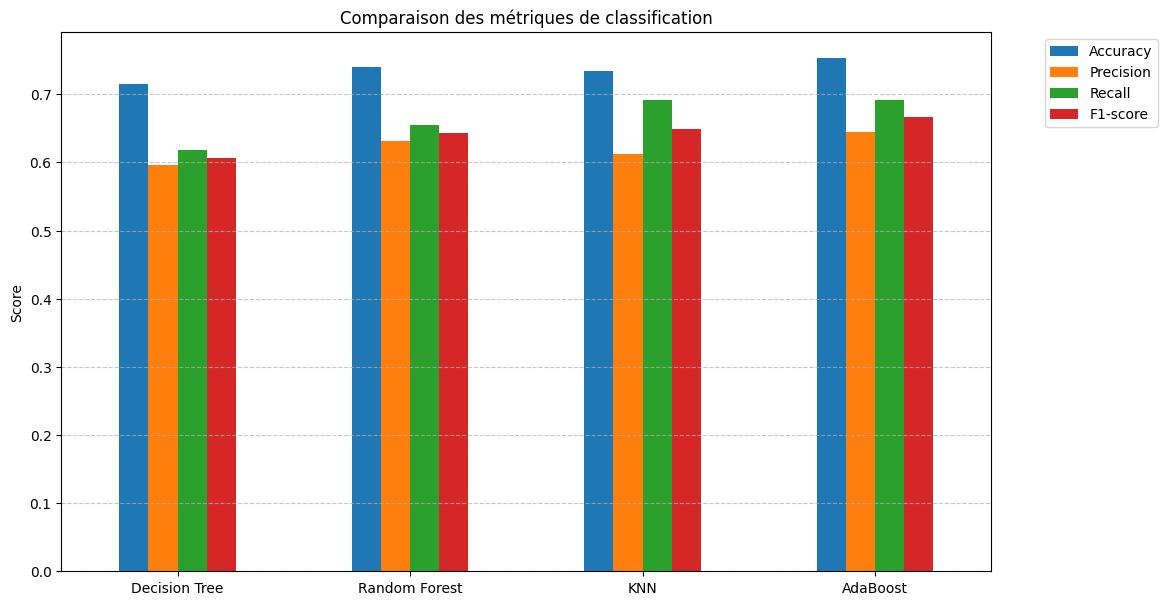

               Accuracy  Precision    Recall  F1-score
Decision Tree  0.714286   0.596491  0.618182  0.607143
Random Forest  0.740260   0.631579  0.654545  0.642857
KNN            0.733766   0.612903  0.690909  0.649573
AdaBoost       0.753247   0.644068  0.690909  0.666667


In [15]:
# Conversion en DataFrame pour l'affichage 
df_results = pd.DataFrame(final_scores).T

# Création du graphique
df_results.plot(kind='bar', figsize=(12, 7))
plt.title("Comparaison des métriques de classification")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(df_results)

## IV. Clustering non supervisé

### K-means

c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:14

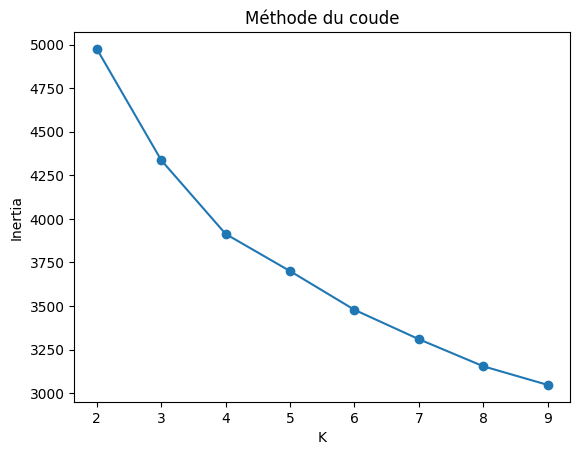

In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title("Méthode du coude")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()



### Silhouette

c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:14

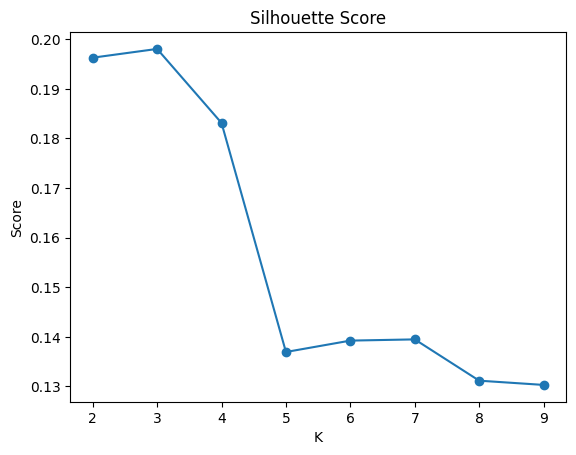

Meilleur K = 3 nous allons donc utiliser ce nombre de clusters pour notre analyse.


In [17]:
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print("Meilleur K =", best_k, "nous allons donc utiliser ce nombre de clusters pour notre analyse.")


### K-means final

c:\Users\leoni\anaconda3\Nouveau dossier\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


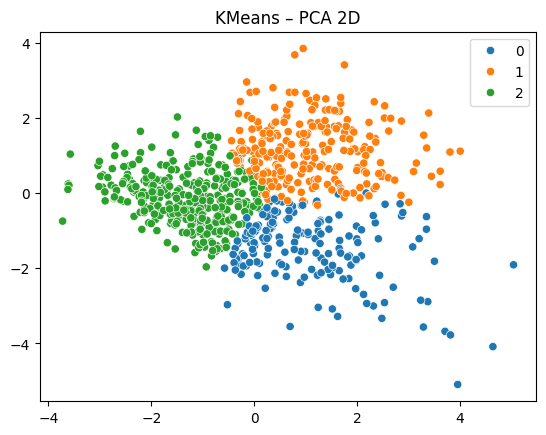

In [18]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters_km = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_km, palette='tab10')
plt.title("KMeans – PCA 2D")
plt.show()

Le K-means à séparer et regroupé chaque individus dans les cluster qui leur étaient le plus proche.

### Dendrome

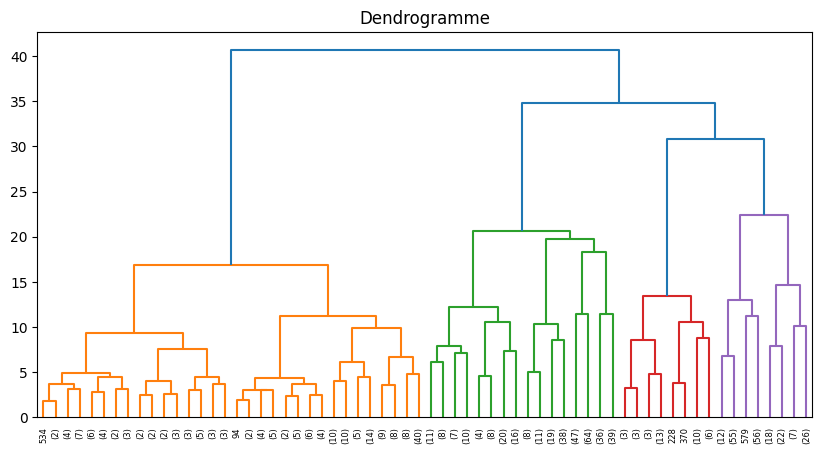

In [19]:

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogramme")
plt.show()


### Clustering hierarchique

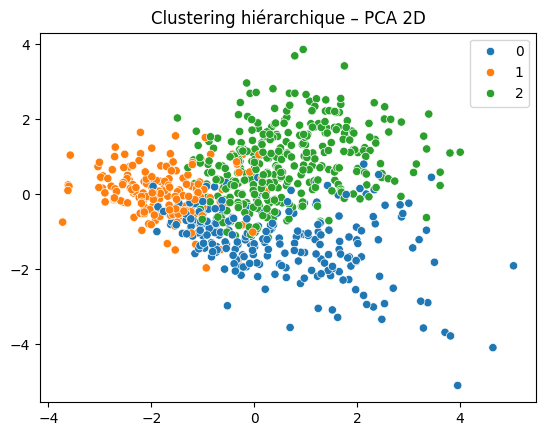

In [20]:
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
clusters_hc = hc.fit_predict(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_hc, palette='tab10')
plt.title("Clustering hiérarchique – PCA 2D")
plt.show()